### OpenCV(Open Source Computer Vision) 개요
- Computer Vision : 사람의 시각적인 부분을 기계로 구현하는 것을 목적으로 하는 딥러닝 분야
- OpenCV : 이미지, 동영상 등의 처리를 지원하는 라이브러리
    - C++로 제작되어 있고, Java, JS, Android, Python 등 다양한 언어에서 활용가능
    - 특히 파이썬에서 사용할 경우 Numpy, Matplotlib 등의 라이브러리와 바로 연동 가능
    

- https://opencv.org/ : OpenCV 공식 사이트
- https://github.com/opencv/opencv : OpenCV github 사이트

In [1]:
# OpenCV 설치
# !pip install opencv-python

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 # OpenCV 임포트

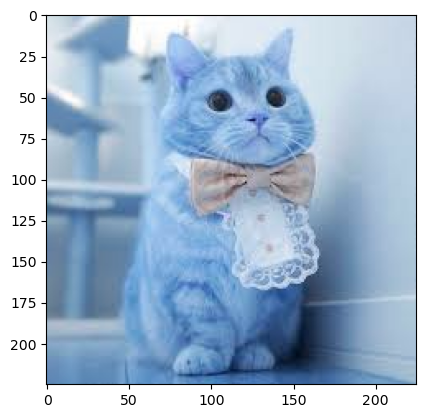

In [3]:
cat = cv2.imread('image/image_cat.JPG')
plt.imshow(cat);

In [4]:
cat

array([[[213, 225, 229],
        [213, 225, 229],
        [210, 224, 230],
        ...,
        [200, 215, 231],
        [200, 215, 231],
        [196, 211, 227]],

       [[214, 226, 230],
        [213, 225, 229],
        [210, 224, 230],
        ...,
        [200, 215, 231],
        [200, 215, 231],
        [191, 206, 222]],

       [[214, 226, 230],
        [214, 226, 230],
        [213, 225, 231],
        ...,
        [200, 215, 231],
        [200, 215, 231],
        [196, 211, 227]],

       ...,

       [[ 96, 134, 182],
        [ 96, 134, 182],
        [ 94, 134, 182],
        ...,
        [161, 190, 211],
        [164, 191, 212],
        [163, 187, 209]],

       [[ 94, 134, 182],
        [ 94, 135, 180],
        [ 94, 134, 182],
        ...,
        [149, 180, 205],
        [152, 183, 206],
        [159, 187, 211]],

       [[ 97, 139, 184],
        [ 95, 138, 181],
        [ 93, 135, 180],
        ...,
        [127, 163, 193],
        [132, 166, 195],
        [138, 171, 197]]

### OpenCV의 색상 체계
- 일반적인 이미지를 matplotlib으로 출력 시 RGB 색상 체계를 사용
- OpenCV는 BGR 색상 체계를 사용 (RBG의 순서가 바뀜!)
- 그래서 RGB이미지를 cv2로 불러와서 matplotlib으로 출력하면 Red계열 색상이 Blue계열 색상으로 변경되어 출력됨
- 초창기에는 알파벳 순서대로 BGR로 표현했고, 이후에 색상 주파수에 낮은 순서대로 바뀌어서 대중적으로 RGB로 사용함
- OpenCV에서 RGB 이미지를 그대로 표현하려면 변환의 단계를 거쳐 출력해야함

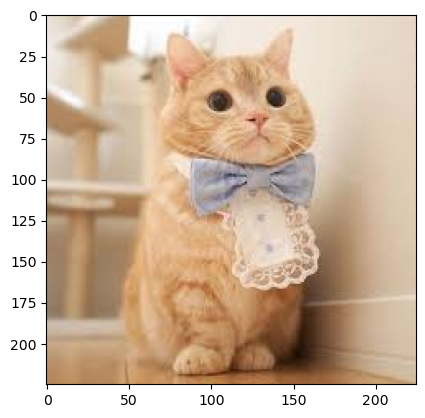

In [5]:
cat = cv2.imread('image/image_cat.JPG')
cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)
plt.imshow(cat);

In [6]:
cat # R과 B 자리만 바뀜

array([[[229, 225, 213],
        [229, 225, 213],
        [230, 224, 210],
        ...,
        [231, 215, 200],
        [231, 215, 200],
        [227, 211, 196]],

       [[230, 226, 214],
        [229, 225, 213],
        [230, 224, 210],
        ...,
        [231, 215, 200],
        [231, 215, 200],
        [222, 206, 191]],

       [[230, 226, 214],
        [230, 226, 214],
        [231, 225, 213],
        ...,
        [231, 215, 200],
        [231, 215, 200],
        [227, 211, 196]],

       ...,

       [[182, 134,  96],
        [182, 134,  96],
        [182, 134,  94],
        ...,
        [211, 190, 161],
        [212, 191, 164],
        [209, 187, 163]],

       [[182, 134,  94],
        [180, 135,  94],
        [182, 134,  94],
        ...,
        [205, 180, 149],
        [206, 183, 152],
        [211, 187, 159]],

       [[184, 139,  97],
        [181, 138,  95],
        [180, 135,  93],
        ...,
        [193, 163, 127],
        [195, 166, 132],
        [197, 171, 138]]

In [7]:
print(cat.shape) # 세로픽셀수, 가로픽셀수, 채널수(컬러는 3)
print(cat.size)  # 전체 데이터 값 개수
print(cat.dtype) # 데이터 타입
    # unint8 (unsigned interger) : 부호가 없는 정수

(225, 225, 3)
151875
uint8


### 이미지 색상 종류
- 컬러 이미지(RGB)
- 흑백 이미지(Gray) → 0~255사이의 흑백 픽셀값으로 구성된 이미지
    - 컬러 이미지는 용량이 크고 연산량이 많기 때문에 이를 간소화 시켜 처리하기 위해서 흑백이미지를 사용함
- 이진 이미지(binary) → 0과 255 두 가지 값으로만 구성된 이미지
    - 배경과 객체를 잘 구분
    - 관심 영역과 비관심 영역을 구분
    - 필터를 만들거나 단순한 이미지 처리를 하는 경우에 사용

1. 기존 컬러 이미지를 Gray로 불러서 받아주고 출력하기

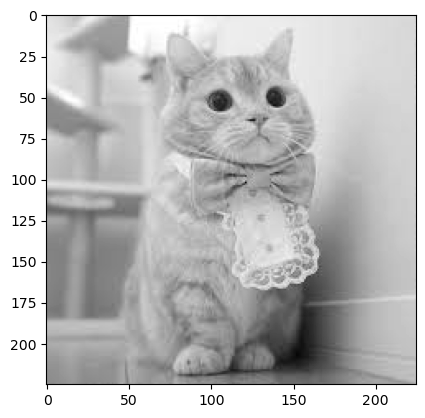

In [8]:
# 이미지를 불러올 때 gray로 받아주고, 출력할때도 gray로 설정해줘야 함
cat_gray = cv2.imread('image/image_cat.JPG', cv2.IMREAD_GRAYSCALE)
plt.imshow(cat_gray, cmap='gray');

2. 컬러 이미지를 그대로 불러서 cvtColor를 통해 gray로 변환 후 츨력

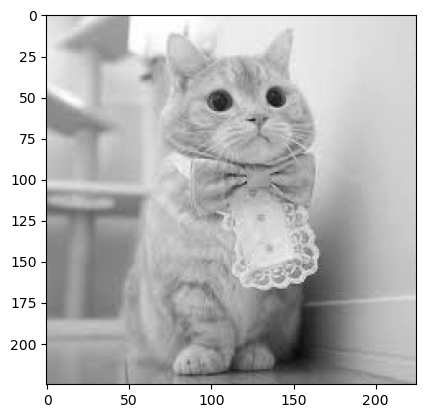

In [9]:
cat2 = cv2.imread('image/image_cat.JPG')
# 불러온 컬러 이미지르 gray로 변환
cat2_gray = cv2.cvtColor(cat2, cv2.COLOR_BGR2GRAY)
plt.imshow(cat2_gray, cmap='gray');

#### 이진(binary) 이미지 만들기
- 기존 이미지가 컬러 이미지라면 gray이미지로 변환 후 이진으로 바꿔줘야 함

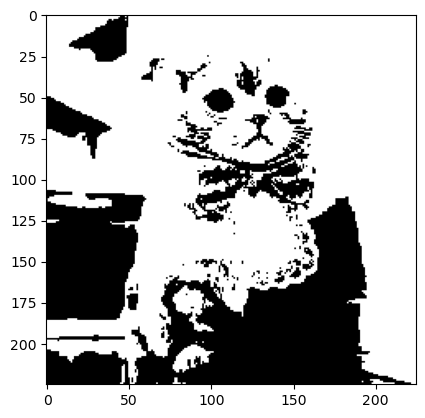

In [10]:
# threshold(문턱값, 경계값) : 특정 기준값을 통해서 데이터를 변환시켜주는 함수
# (gray이미지, 경계기준값, 경계값보다 클 때 적용되는 값, 경계값 적용방식)
_, bi_cat = cv2.threshold(cat2_gray, 165, 255, cv2.THRESH_BINARY)

# _ : 첫번째 리턴 값은 받지 않음(threshold함수는 두 가지 값이 리턴됨)
# 리턴 값의 첫 번째는 경계값 수치, 두번째는 경계값 기준이 적용된 이미지

plt.imshow(bi_cat, cmap='gray');

In [11]:
_ # 첫번째 리턴 값

165.0

In [12]:
bi_cat # 두번째 리턴 값

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]], dtype=uint8)

#### cv2.threshold(gray_img, threshold_value, value, flag)
- gray_img : 그레이 이미지
- threshold_value : 경계 기준값
- value : 경계값보다 클 때 적용되는 값
- flag : 경계값 적용 방식
    - cv2.THRESH_BINARY : 픽셀값이 경계값보다 크면 value, 아니면 0을 할당 (흰/검으로만 표시)
    - cv2.THRESH_BINARY_INV : 픽셀값이 경계값보다 크면 0, 아니면 value 할당
    - cv2.THRESH_TRUNC : 픽셀값이 경계값보다 크면 경계값, 아니면 픽셀값 할당 (가장 흰 부분이 경계값으로 표시)
    - cv2.THRESH_TOZERO : 픽셀값이 경계값보다 크면 픽셀값, 아니면 0을 할당(검은색 부각)
    - cv2.THRESH_TOZERO_INV : 픽셀값이 경계값보다 크면 0, 아니면 픽셀값 할당
    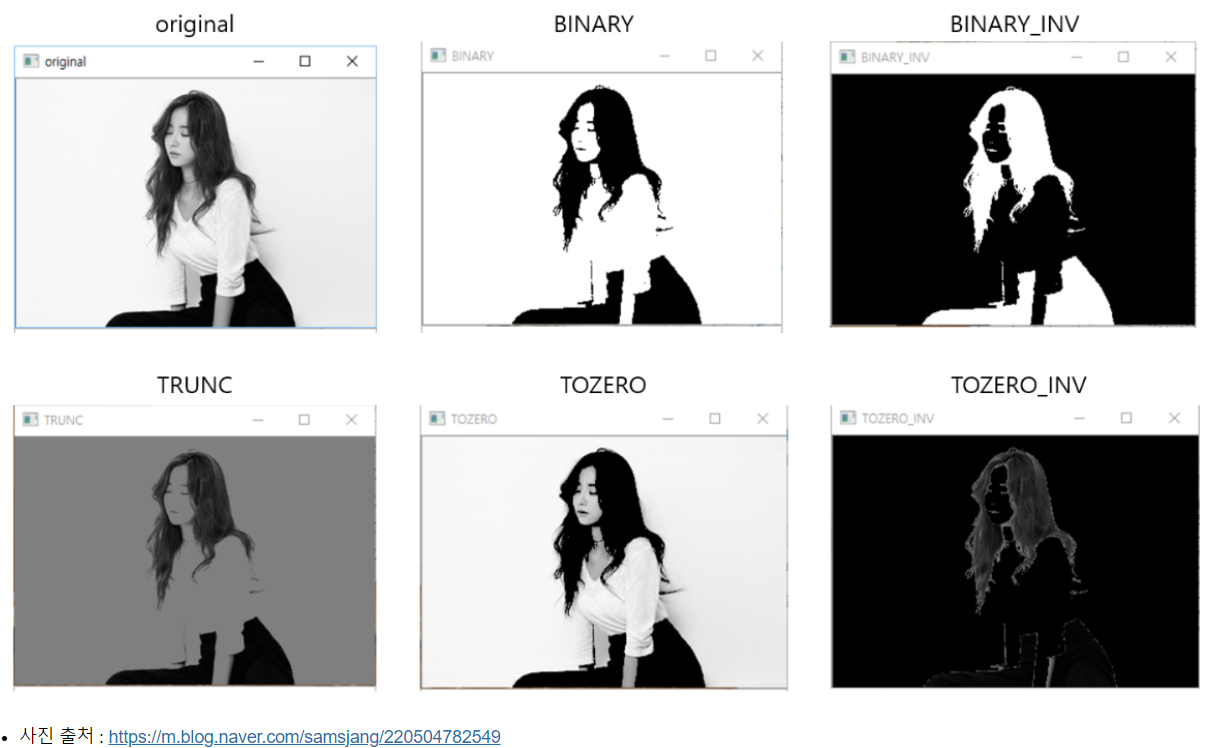

### 동영상 혹은 카메라(웹 캠) 불러오기

비디오 캡처 성공^_^
읽기 성공 여부 :  True
프레임 shape :  (358, 640, 3)
[[[ 89 151 176]
  [ 89 151 176]
  [ 88 150 175]
  ...
  [ 21 129 177]
  [ 21 129 177]
  [  4 112 160]]

 [[118 180 205]
  [118 180 205]
  [118 180 205]
  ...
  [ 35 143 191]
  [ 35 143 191]
  [ 18 126 174]]

 [[125 187 212]
  [125 187 212]
  [125 187 212]
  ...
  [ 47 155 203]
  [ 47 155 203]
  [ 29 137 185]]

 ...

 [[ 41  68  71]
  [ 41  68  71]
  [ 41  68  71]
  ...
  [ 10  40  49]
  [ 10  40  49]
  [ 10  40  49]]

 [[ 18  45  48]
  [ 18  45  48]
  [ 18  45  48]
  ...
  [ 15  29  41]
  [ 15  29  41]
  [ 15  29  41]]

 [[  0  27  30]
  [  0  27  30]
  [  0  27  30]
  ...
  [  0  14  26]
  [  0  14  26]
  [  0  14  26]]]


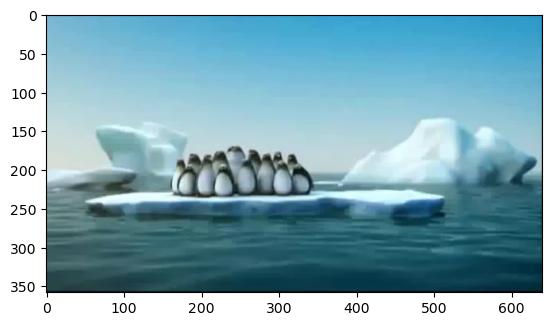

In [13]:
# 영상에 있는 프레임 출력해보기
'''영상을 다룰 때는 연속된 프레임을 실시간으로 처리해주기 때문에 제대로
    동작하지 않았을 경우에 대한 예외처리를 해주는 것이 오류로 인한 중단을
    방지하거나 오류의 위치를 파악함에 있어서 유리함'''

# 1. 영상에서 프레임을 캡처
# 코드 실행에 문제가 없을 경우
try :
    # 1) 카메라(웹캠)으로부터 캡처(일반적으로 내장 카메라는 0번으로 인식)
#     cap = cv2.VideoCapture(0)
    # 2) 동영상으로부터 캡처
    cap = cv2.VideoCapture("image/video.mp4")
    print("비디오 캡처 성공^_^")
# 코드 실행에 문제가 생길 경우
except :
    print("비디오 캡처 실패 ㅠㅠ")
    
# 2. 캡처해 온 프레임을 읽고 출력시키기
# read : 캡처한 이미지 프레임을 한 장씩 읽어옴
ret, frame = cap.read()

    # ret : 읽기 성공여부(True,False)
    # frame : 실제 이미지의 배열 데이터
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


print("읽기 성공 여부 : ", ret)
print("프레임 shape : ", frame.shape)
print(frame)
plt.imshow(frame);

### 동영상 읽어와서 동영상으로 출력하기

In [14]:
try :
    cap = cv2.VideoCapture(0)
#     cap = cv2.VideoCapture("image/video.mp4")
    print("비디오 캡쳐 시작~!")
except :
    print("비디오 캡쳐 실패ㅠㅠ")
    
# 캡쳐해온 프레임을 계속해서 한 장씩 읽어와 연결하여 출력(영상으로 보여주기)
while True :
    ret, frame = cap.read()
    '''
        폭력감지 영상 판단을 예로 들면 CCTV영상에서 frame 단위로 이미지를
        읽어온 후, 폭력 이미지인지 아닌지를 판단하는 딥러닝 모델에 넣어서
        model.predict(frame)로 영상의 각 프레임들이 폭력인지 아닌지를 판단
        해 내도록 할 수 있음.
        단 모델이 무겁다면 예측하는데 시간이 많이 소요되기 때문에 실시간 
        판단이 힘들어지거나 출력되는 영상의 초당 프레임(FPS)가 떨어지는 
        현상이 발생할 수 있음
    '''
    
    # 영상 반전 (1:좌우반전, 0:상하반전)
    frame = cv2.flip(frame, 1)
    # 영상 사이즈 설정
    frame = cv2.resize(frame, (500,300))
    # 흑백 영상 설정
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    
    # 영상으로부터 프레임을 받아오지 못했거나, 다 읽었을 경우 메모리 할당 끊기
    if ret == False :
        print("프레임 읽기 실패 or 프레임 모두 읾음!")
        cap.release()
        cv2.destroyAllWindows()
        break
        
    # imshow : 새 윈도우 창을 띄워서 이미지 혹은 영상 출력(윈도우 창 이름, 프레임)
    cv2.imshow("video^^", frame)
    
    # waitKey : 키보드의 특정 값을 입력받을 때까지 기다리며 지정된 시간만큼 대기하는 함수
    # 한 장의 프레임을 알고 40ms 후 다음 프레임 읽어들임(우리 영상은 초당 25프레임)
    key = cv2.waitKey(40)
    '''
        - 일반적으로 동영상을 초당 30장 이상의 프레임으로 출력하면 부드러운 영상
        - waitKey 괄호 안의 시간 단위는 ms이므로 실제 1초는 숫자 1000이 됨
        - 영상의 실제 프레임수와 waitKey값이 차이가 나면 플레이 자체는 문제가 없지만
            뒤쪽 프레임 일부가 잘려서 실행될 수도 있음
        - 영상의 초당 프레임수가 다르면 거기에 맞춰 딜레이 시간을 설정해줘야함
            ex) 영상이 초당 60프레임이라면 16 or 17ms 로 설정하기!
    '''
    
    # 재생 도중 영상을 끄고 싶을 경우 (위도우창 X를 누르면 커널을 재시작해야함!)
    # 아스키코드 : 미국표준협회에서 제시한 표준 코드 체계
        # (키보드의 키값들을 코드에서 숫자로 표현 가능)
        # 27 : ESC키
        # 49 : 키보드 숫자 1
    if key == 27 :
        print("동영상 읽기 종료")
        cap.release()
        cv2.destroyAllWindows()
        break

비디오 캡쳐 시작~!
동영상 읽기 종료


### 동영상 캡쳐 및 녹화하고 저장하기

In [15]:
try :
    cap = cv2.VideoCapture(0)
    print("비디오 캡쳐 시작 ~!")
except :
    print("비디오 캡쳐 실패ㅠㅠ")
    
fps = 25.0             # 초당 프레임 이미지 수
w = int(cap.get(3))    # 3 : 캡쳐한 비디오 프레임의 가로 크기
h = int(cap.get(4))    # 4 : 캡쳐한 비디오 프레임의 세로 크기
# 영상 코덱 설정(CODEC : COder and DECoder)
# coder : 음성 또는 영상의 신호를 디지털 신호로 변환(decoder는 coder의 반대)
codec = cv2.VideoWriter_fourcc(*'DIVX')  # 가장 일반적인 영상 코덱

# 저장될 녹화 영상 파일 설정(파일명, 코덱, 속도, 크기)
out = cv2.VideoWriter('image/record_file.avi', codec, fps, (w,h))

# 녹화 상태 여부
record = False
cnt = 1

while True :
    ret, frame = cap.read()
    frame = cv2.flip(frame, 1)
    
    if ret == False :
        print("비디오 읽기 실패 or 모두 읽음!")
        cap.release()
        # 출력해줄 녹화 영상의 이미지들을 담아두는 out 변수의 메모리 할당도 끊기
        out.release()
        cv2,destroyAllWindows()
        break
    
    # 창 띄우기
    cv2.imshow("record^^", frame)
    
    # record가 True 설정되면 영상 녹화를 시작
    if record == True :
        # write : 프레임 데이터 읽고 쓰기 (읽어온 프레임으로 출력 영상 만들기)
        out.write(frame)
    
    key = cv2.waitKey(40)
    
    # 키보드 숫자 1 누르면, 이미지 캡쳐
    if key == 49 :    # 키보드 숫자 1번을 눌렀을 경우
        print(f"이미지를 캡쳐합니다_{cnt}번째!")
        record = True
        # imwrite : 프레임 저장 함수
        cv2.imwrite(f"image/captured_img_{cnt}.jpg",frame)
        cnt += 1
    # 키보드 숫자 2 누르면, 영상 녹화
    if key == 50 :
        print("녹화를 시작합니다.")
        record = True
        
    # 키보드 ESC 누르면, 영상 끄기
    if key == 27 :
        print("녹화를 종료하고 창을 닫습니다.")
        cap.release()
        out.release()
        cv2.destroyAllWindows()
        break

비디오 캡쳐 시작 ~!
녹화를 종료하고 창을 닫습니다.


### 이미지 픽셀값 변경하기

[162 145 153]


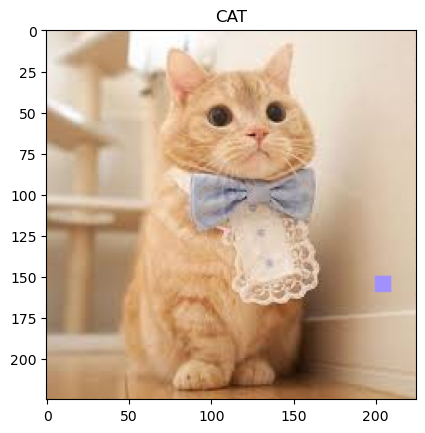

In [16]:
cat = cv2.imread('image/image_cat.JPG')
cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)

# 픽셀값 하나를 읽어서 RGB로 출력(고양이 리본쪽)
print(cat[110,100]) # [세로픽셀, 가로픽셀]

# [세로범위(위-아래), 가로범위(좌-우)]
cat[150:160, 200:210] = [160, 145, 255] # [R, G, B]

plt.title('CAT')
plt.imshow(cat);

### ROI(Region of Interest) 관심영역 추출하기

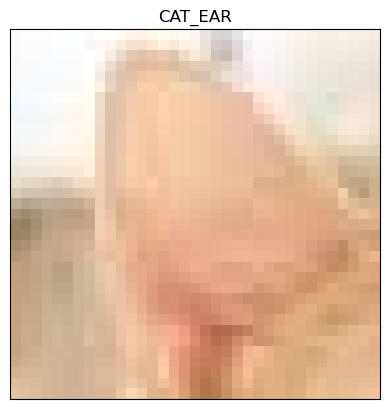

In [17]:
roi_cat = cat[10:45,65:100]

# x축, y축 값 없애기
plt.xticks([]); plt.yticks([])

plt.title('CAT_EAR')
plt.imshow(roi_cat);

### ROI 영역을 그림으로 표시하고 문자로 출력해보자!
- line : 선을 그리는 함수
- rectangle : 사각형을 그리는 함수
- circle : 원을 그리는 함수
- putText : 텍스트 출력 함수

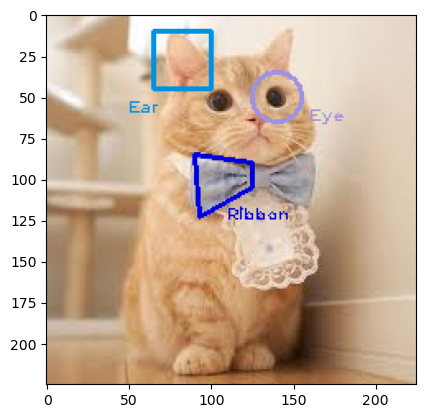

In [18]:
cat = cv2.imread('image/image_cat.JPG')
cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)

# line(이미지, 시작좌표, 끝좌표, RGB, 선의두께)
cat = cv2.line(cat, (90,85),(125,90),(0,0,225),2)
cat = cv2.line(cat, (93,123),(125,105),(0,0,225),2)
cat = cv2.line(cat, (93,123),(90,85),(0,0,225),2)
cat = cv2.line(cat, (125,90),(125,105),(0,0,225),2)

# ractangle(이미지, 좌상단좌표, 우하단좌표, RGB, 선의두께)
cat = cv2.rectangle(cat, (65,10), (100,45), (0,145,225), 2)

# circle(이미지, 중심좌표, 라디안(반지름), RGB, 선의두께)
cat = cv2.circle(cat, (140,50), (15), (160,145,225), 2)

# putText(이미지, 출력글씨, 출력위치의 좌측하단좌표, 폰트, 폰트크기, RGB, 선의두께)
cat = cv2.putText(cat, "Ribbon", (110,125), cv2.FONT_HERSHEY_PLAIN, 0.7, (0,0,225),1)
cat = cv2.putText(cat, "Ear", (50,60), cv2.FONT_HERSHEY_PLAIN, 0.7, (0,145,225),1)
cat = cv2.putText(cat, "Eye", (160,65), cv2.FONT_HERSHEY_PLAIN, 0.7, (160,145,225),1)



plt.imshow(cat);

#### 한글 폰트 출력
- OpenCV에서는 한글 출력이 불가
- PIL 라이브러리를 활용하여 이미지 위에 문자가 들어있는 이미지를 덧씌워주는 개념으로 실행해보자!

In [19]:
from PIL import ImageFont, ImageDraw, Image

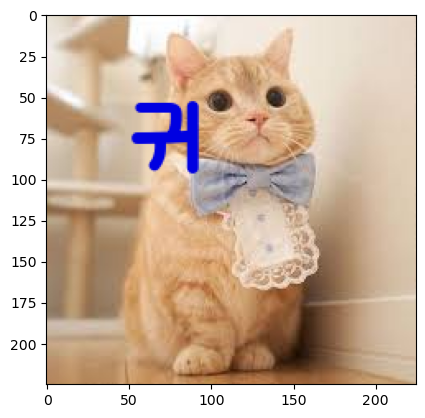

In [29]:
cat = cv2.imread('image/image_cat.JPG')
cat = cv2.cvtColor(cat, cv2.COLOR_BGR2RGB)

# 폰트 및 폰트 크기 설정
test_font = ImageFont.truetype('fonts/gulim.ttc', 50)

# PIL라이브러리가 사용할 수 있게끔 기존 배열 데이터를 이미지 객체로 변경
cat_pil = Image.fromarray(cat)

# 이미지(cat_pil)위에 도형/폰트를 출력하 공간 만들어주기
draw = ImageDraw.Draw(cat_pil)
# text((출력위치의 좌측상단좌표), '출력내용', font=ImageFont.truetype(), fill=(R,G,B,투명도), stroke_width=폰트두께)
draw.text((50,50), '귀', font=test_font, fill=(0,0,225,0), stroke_width=2)
    # 한글 출력시에는 영문(좌하단)과 다르게 글씨의 좌상단 좌표를 써줘야함!
    # fill에서 4번째 값은 Alpha값(투명도) - openCV에서는 투명도 값 조절을 지원하지 않음
    
img = np.array(cat_pil)
plt.imshow(img);

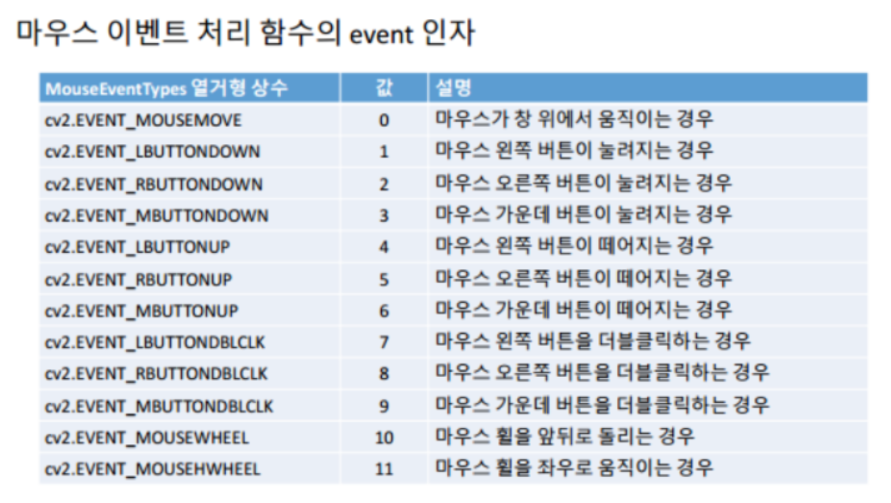
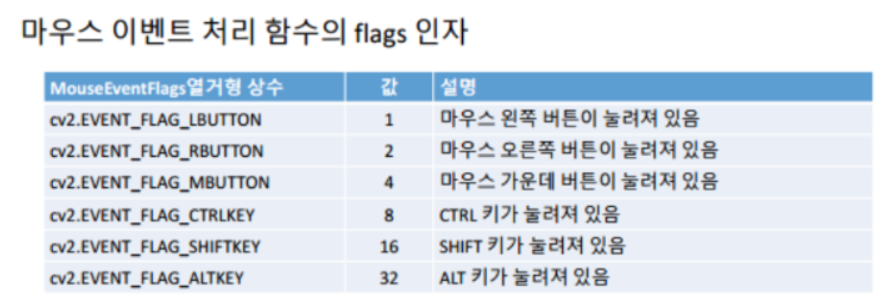

In [36]:
'''
    마우스 이벤트를 지원하는 setMouseCallback함수를 적용하기 위해서는
    사전에 사용자 정의함수가 선언되어 있어야 함
'''

# 사각형의 시작점과 끝점ㅁ을 지정하기 위해서는 x,y변수 외에 한 셋트가 더 필요함
# 좌표값은 항상 양수이므로 사용하지 않는 음수 값으로 초기화
x1, y1 = -1, -1

'''
    event : 마우스 이번테의 종류
    x, y : 마우스 이벤트가 시행된  좌표
    flags : 마우스 이벤트 발생시의 상태
    img : 적용될 입력 이미지
'''
def rectangle(event, x, y, flags, img) :
    # global : 전역변수 설정
    global x1, y1
    
    if event == cv2.EVENT_LBUTTONDOWN : # 마우스 좌클릭된 경우
        x1, y1 = x, y # 클릭이 시행된 좌표
        print(f"사각형 좌상단 좌표 : {x1}, {y1}")
    elif event == cv2.EVENT_LBUTTONUP : # 마우스 좌클릭 떼어진 경우
        # x, y 는 마우스 드래크가 끝나면서 좌클릭이 떼질 때의 사각형 우하단 좌표
        cv2.rectangle(img, (x1, y1), (x, y), (160,145,255), 2)
        print(f"사각형 우하단 좌표 : {x}, {y}")

In [40]:
img = cv2.imread('image/image_cat.JPG')

# 생성된 윈도우 창의 이름 설정
cv2.namedWindow('figure')

# setMouseCallback('윈도우창에 설정한 이름', 사용자 정의 함수, 이미지)
cv2.setMouseCallback('figure', rectangle, img)

while True :
    cv2.imshow('figure', img)
    # 마우스 이벤트 실행 후 사각형이 그려진 프레임이 보이기 까지의 시간
    key = cv2.waitKey(1)
    
    if key == 27:
        cv2.destroyAllWindows()
        break

사각형 좌상단 좌표 : 72, 10
사각형 우하단 좌표 : 103, 36
사각형 좌상단 좌표 : 135, 6
사각형 우하단 좌표 : 152, 37
사각형 좌상단 좌표 : 86, 30
사각형 우하단 좌표 : 167, 90
사각형 좌상단 좌표 : 84, 84
사각형 우하단 좌표 : 175, 109
사각형 좌상단 좌표 : 110, 102
사각형 우하단 좌표 : 154, 153
사각형 좌상단 좌표 : 80, 200
사각형 우하단 좌표 : 108, 215
사각형 좌상단 좌표 : 117, 204
사각형 우하단 좌표 : 147, 215
사각형 좌상단 좌표 : 68, 84
사각형 우하단 좌표 : 157, 199


### 색상 추적
- RGB 색상 : 색의 2요소만 가지고 색상을 판단
    - 채도, 명도에 따라 변화가 심함 -> 어떤 색인지 명확하게 알기가 힘듦
        - 채도 : 탁한 정도(수치가 낮으면 탁해짐)
        - 명도 : 밝기 정도(수치가 클수록 밝아짐)
- HSV 색상 : 색상과 채도, 명도를 종합적으로 판단하는 색 체계
    - H(hue:색상), S(saturation:채도), V(value:명도)
        - 색상 : 각도 수치로 표시(0~360), 빨강부터 무지개색 순서, 360되면 다시 빨강색!
        -  OpenCV에서는 색의 범위를 0~180으로 제한해서 사용하며 HSV색상표에서 1/2으로 줄여서 적용함
        - 채도 : 0~100 값, 수치가 낮을수록 탁해짐
        - 명도 : 0~100 값, 수치가 클수록 밝아짐
    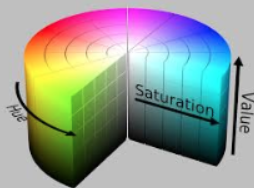

#### HSV색상표
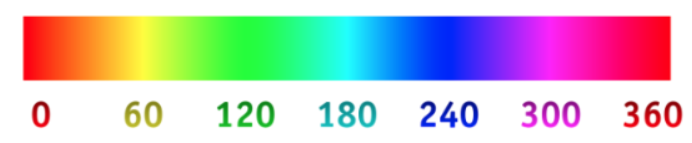

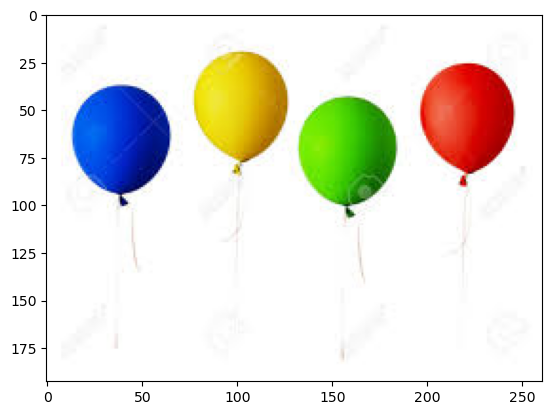

In [41]:
img = cv2.imread('image/balloon.JPG')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img);

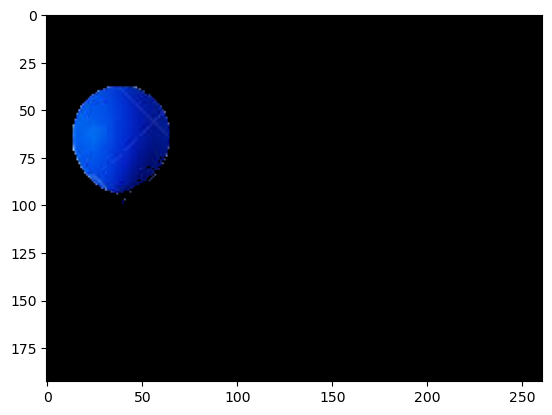

In [55]:
# 색상 체계를 RGB에서 HSV로 변환
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# 파란색 추적
# [색상, 채도, 명도]의 범위를 설정
min_range = np.array([100, 100, 100])
max_range = np.array([130, 255, 255])

# 원하는 색상이 포함된 마스크 이미지 얻어내기
# inRange(hsv색상이미지, 최소범위, 최대범위)
#      : 설정한 범위에 해당하는 픽셀값은 그대로, 나머지는 0(검은색)으로 변환
img_mask = cv2.inRange(hsv, min_range, max_range)

# bitwise_and : 두 개의 이미지에서 공통적인 부분을 bit연산의 and로 진행
'''
    실제 이미지와 마스크 이미지를 and연산하여 해당이미지에도 있고,
    마스크 이미지에도 있는 픽셀을 추출하는 개념
'''
img2 = cv2.bitwise_and(img, img, mask=img_mask)

plt.imshow(img2);

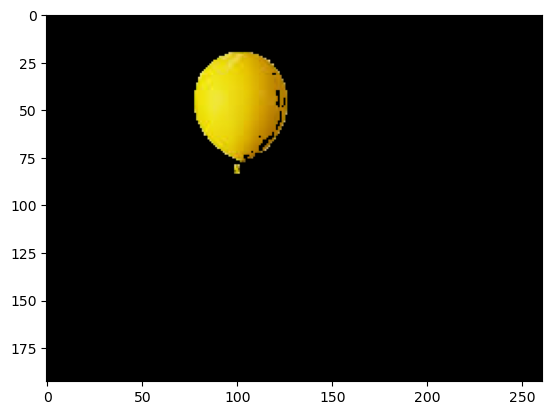

In [57]:
##### 빨간색, 노란색, 초록색 풍선을 각각 출력해보기~! #############
# (채도,명도는 그대로 두고, 색상만 바꾸기!)

# 빨간색 추적
# min_range = np.array([0, 100, 100])
# max_range = np.array([10, 255, 255])

# 노란색 추적
min_range = np.array([20, 100, 100])
max_range = np.array([40, 255, 255])

# 초록색 추적
# min_range = np.array([35, 100, 100])
# max_range = np.array([85, 255, 255])

#####################################################################

img_mask = cv2.inRange(hsv, min_range, max_range)
img2 = cv2.bitwise_and(img, img, mask=img_mask)
plt.imshow(img2);